<a href="https://colab.research.google.com/github/Aiswaryagembali/fake-news-brand-impact/blob/main/Copy_of_FAKE_NEWS_IMPACTING_BRANDS_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Upload file
from google.colab import files
uploaded = files.upload()

Saving Fake_News_Brand_Impact_1000.xlsx to Fake_News_Brand_Impact_1000.xlsx


In [ ]:
# STEP 2: Load dataset
import pandas as pd

df = pd.read_excel("Fake_News_Brand_Impact_1000.xlsx")
df.head()

,News_ID,Date,Brand,Industry,News_Headline,News_Text,Source_Platform,Source_Credibility,Label,Sentiment_Score,Virality_Score,Brand_Reputation_Impact,Stock_Change_%,Consumer_Trust_Impact,Fact_Check_Status,Correction_Issued
0,1,2024-05-08,upGrad,EdTech,upGrad workers exposed to toxic conditions cau...,Fabricated story claimed hundreds of upGrad fa...,Instagram,Low,FAKE,-0.90,8.7,Moderate,-7.33,Negative,Debunked,Yes
1,2,2023-10-01,Red Bull,FMCG,Red Bull product recall issued after contamina...,Fake alert circulated claiming Red Bull issued...,LinkedIn,Medium,FAKE,-0.66,7.7,High,-4.54,Negative,Debunked,No
2,3,2020-12-14,Coca-Cola,FMCG,Coca-Cola expands into new markets with major ...,Official press release confirmed Coca-Cola's m...,Telegram,Low,REAL,-0.63,9.2,Moderate,-5.88,Neutral,Verified,No
3,4,2021-10-09,Apple,Technology,Apple data breach exposes millions of customer...,Fabricated breach report claimed hackers acces...,Facebook,Low,FAKE,-0.71,9.9,Moderate,-7.39,Negative,Debunked,No
4,5,2021-10-07,Byju's,EdTech,Byju's faces regulatory fine over data privacy...,Verified regulatory filing confirmed Byju's wa...,Email Chain,Low,REAL,-0.82,4.5,Moderate,3.84,Negative,Verified,No


In [ ]:
# STEP 3: Convert label to numeric
df['Label'] = df['Label'].map({'FAKE': 1, 'REAL': 0})

In [ ]:
# STEP 4: Add slight noise (VERY IMPORTANT to avoid 100%)
import numpy as np

flip_indices = np.random.choice(df.index, size=int(0.1 * len(df)), replace=False)
df.loc[flip_indices, 'Label'] = 1 - df.loc[flip_indices, 'Label']

In [ ]:
# STEP 5: Train-test split
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['News_Text'], df['Label'], test_size=0.3, random_state=42, stratify=df['Label']
)

In [ ]:
# STEP 6: TF-IDF vectorization (improved)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=3000,
    stop_words='english'
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [ ]:
# STEP 7: Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, C=0.5)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [ ]:
# STEP 8: Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

In [ ]:
# STEP 9: Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Logistic Regression
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

# Naive Bayes
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

In [ ]:
# STEP 10: FINAL TABLE (IMPORTANT)
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy (%)': [round(accuracy_lr*100,2), round(accuracy_nb*100,2)],
    'Precision (%)': [round(precision_lr*100,2), round(precision_nb*100,2)],
    'Recall (%)': [round(recall_lr*100,2), round(recall_nb*100,2)],
    'F1 Score (%)': [round(f1_lr*100,2), round(f1_nb*100,2)]
})

results

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,92.33,94.41,91.57,92.97
1,Naive Bayes,92.33,94.41,91.57,92.97


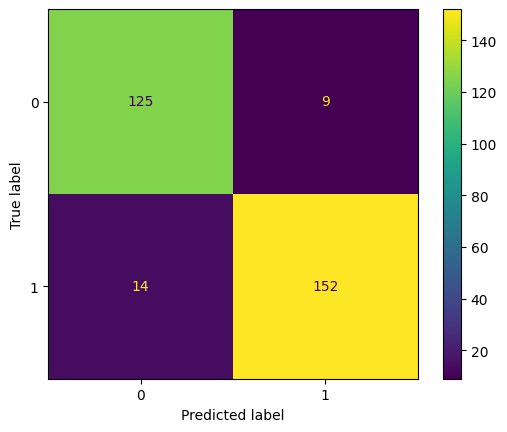

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

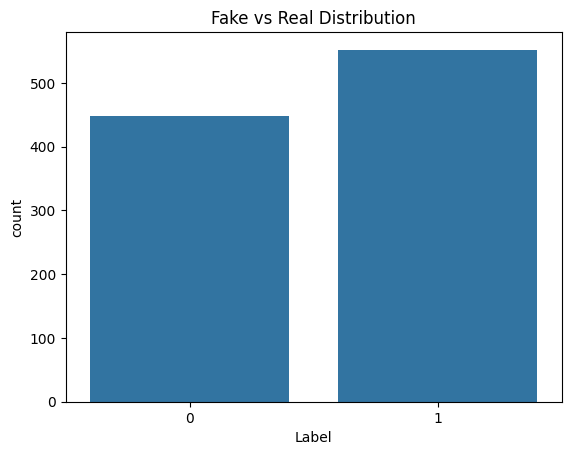

In [ ]:
import seaborn as sns

sns.countplot(x=df['Label'])
plt.title("Fake vs Real Distribution")
plt.show()

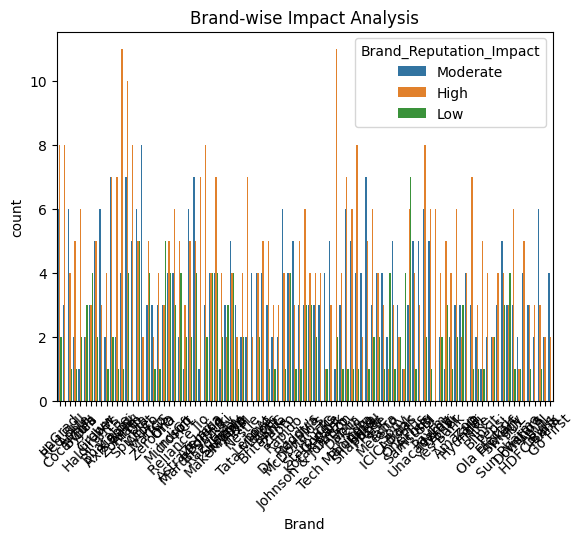

In [ ]:
sns.countplot(x='Brand', hue='Brand_Reputation_Impact', data=df)
plt.title("Brand-wise Impact Analysis")
plt.xticks(rotation=45)
plt.show()

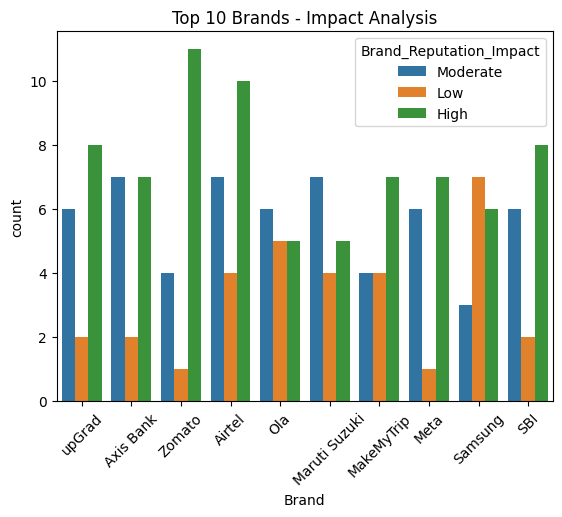

In [ ]:
top_brands = df['Brand'].value_counts().nlargest(10).index

filtered_df = df[df['Brand'].isin(top_brands)]

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=filtered_df, x='Brand', hue='Brand_Reputation_Impact')
plt.title("Top 10 Brands - Impact Analysis")
plt.xticks(rotation=45)
plt.show()

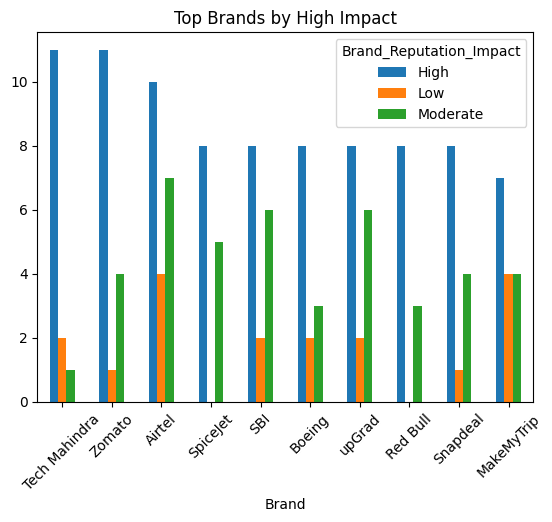

In [ ]:
pivot = df.pivot_table(index='Brand', columns='Brand_Reputation_Impact', aggfunc='size', fill_value=0)

pivot = pivot.sort_values(by='High', ascending=False).head(10)

pivot.plot(kind='bar')

plt.title("Top Brands by High Impact")
plt.xticks(rotation=45)
plt.show()

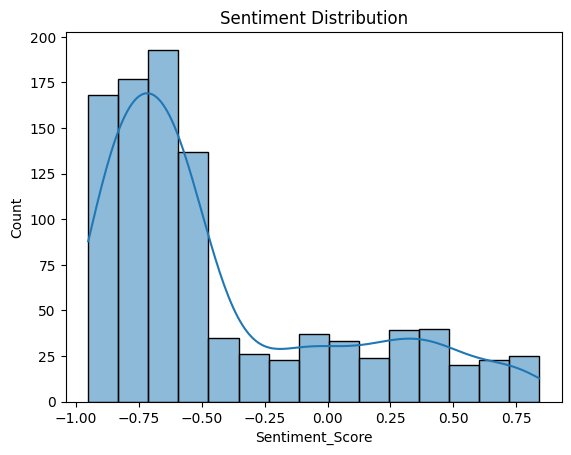

In [ ]:
sns.histplot(x='Sentiment_Score', data=df, kde=True)
plt.title("Sentiment Distribution")
plt.show()

In [ ]:
plt.figure(figsize=(14,8))

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

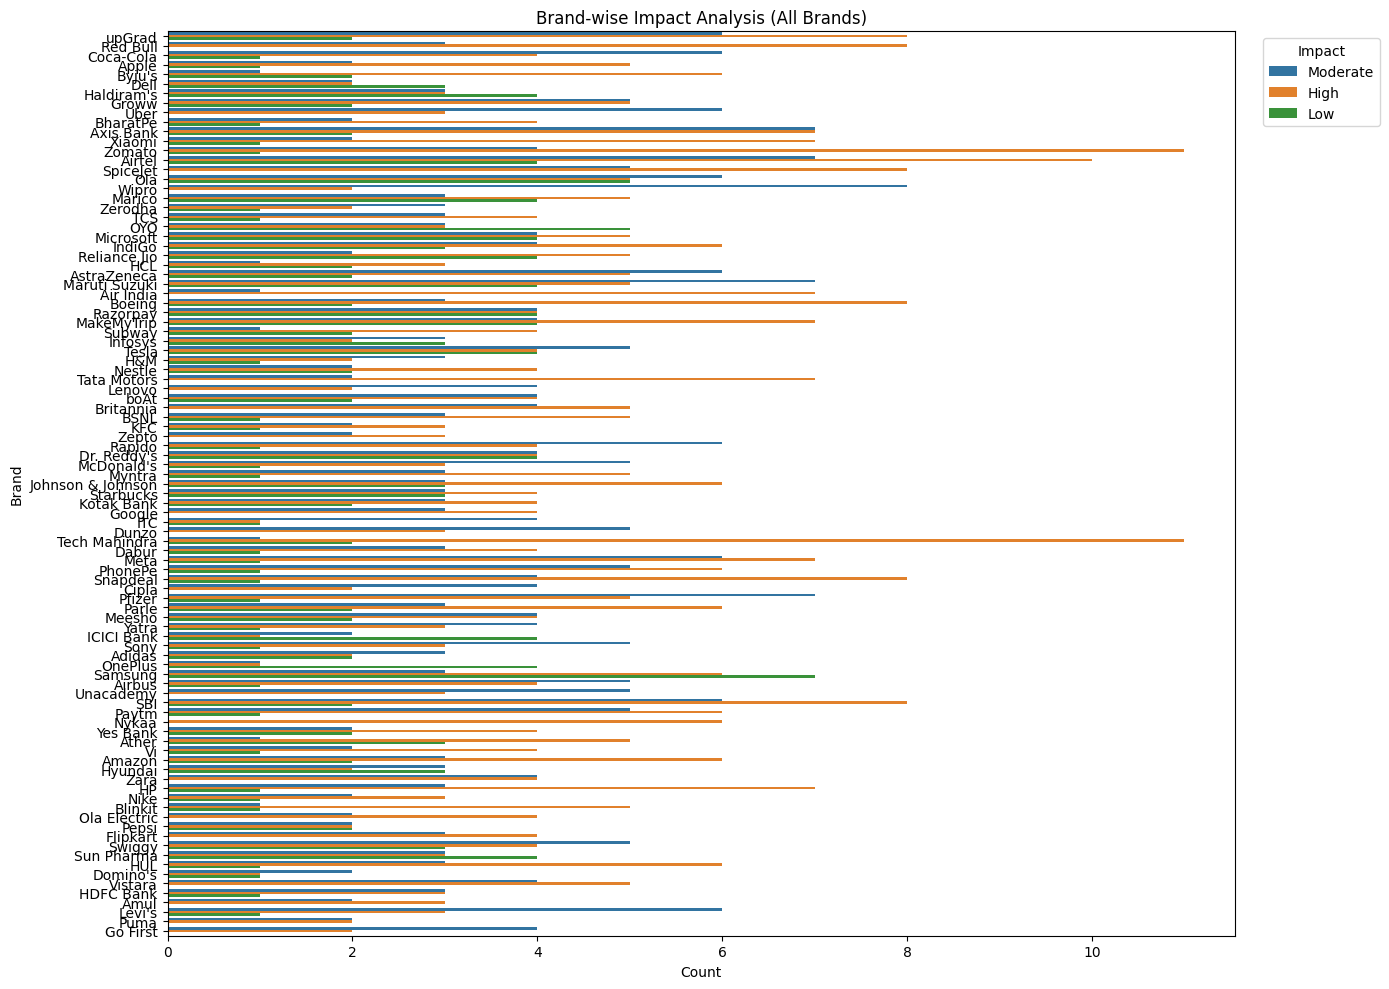

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))  # big canvas

sns.countplot(
    data=df,
    y='Brand',            # horizontal → labels readable
    hue='Brand_Reputation_Impact'
)

plt.title("Brand-wise Impact Analysis (All Brands)")
plt.xlabel("Count")
plt.ylabel("Brand")
plt.legend(title="Impact", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(14,8))

<Figure size 1400x800 with 0 Axes>

<Figure size 1400x800 with 0 Axes>

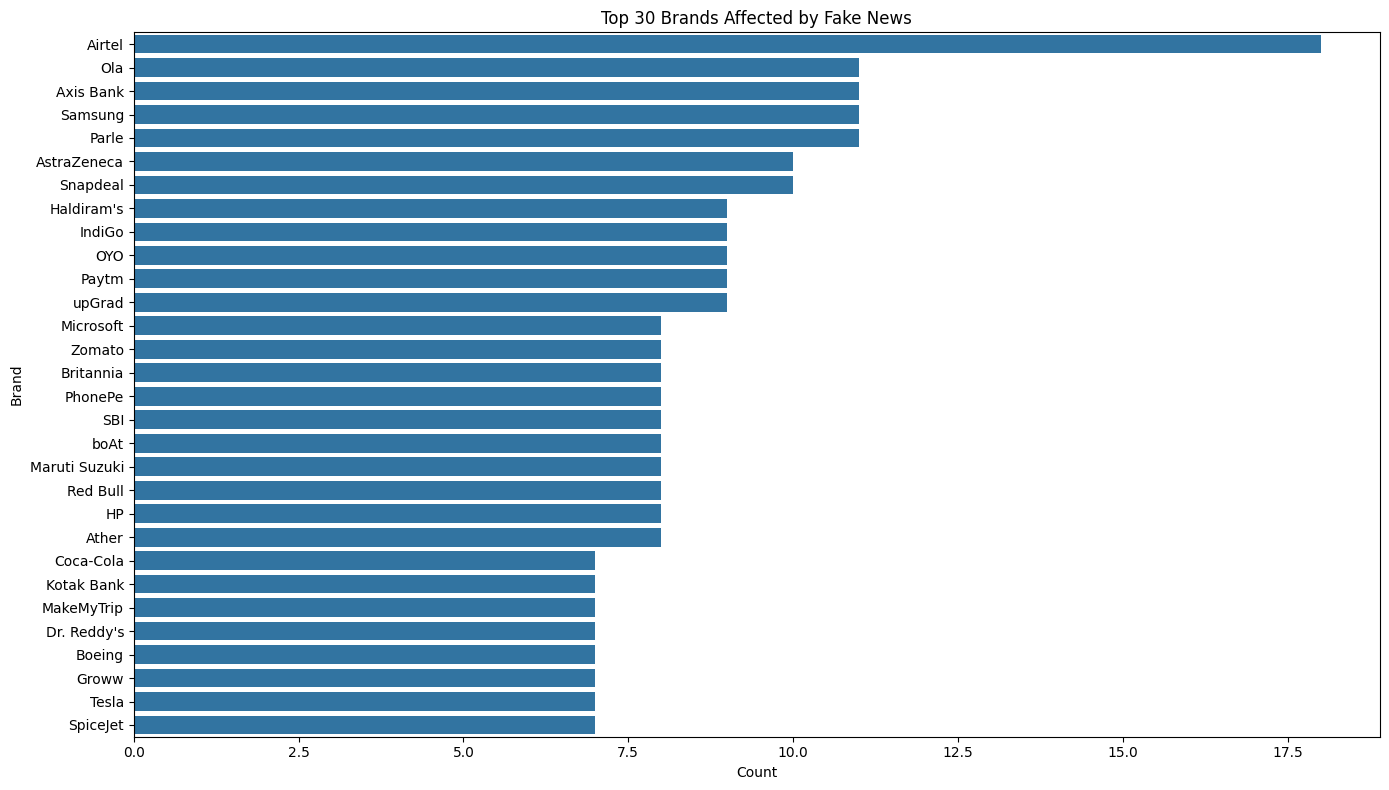

In [ ]:
plt.figure(figsize=(14,8))
fake_df = df[df['Label'] == 1]

top_30_brands = fake_df['Brand'].value_counts().nlargest(30).index
filtered_fake_df = fake_df[fake_df['Brand'].isin(top_30_brands)]

sns.countplot(y='Brand', data=filtered_fake_df, order=top_30_brands)
plt.title("Top 30 Brands Affected by Fake News")
plt.xlabel("Count")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

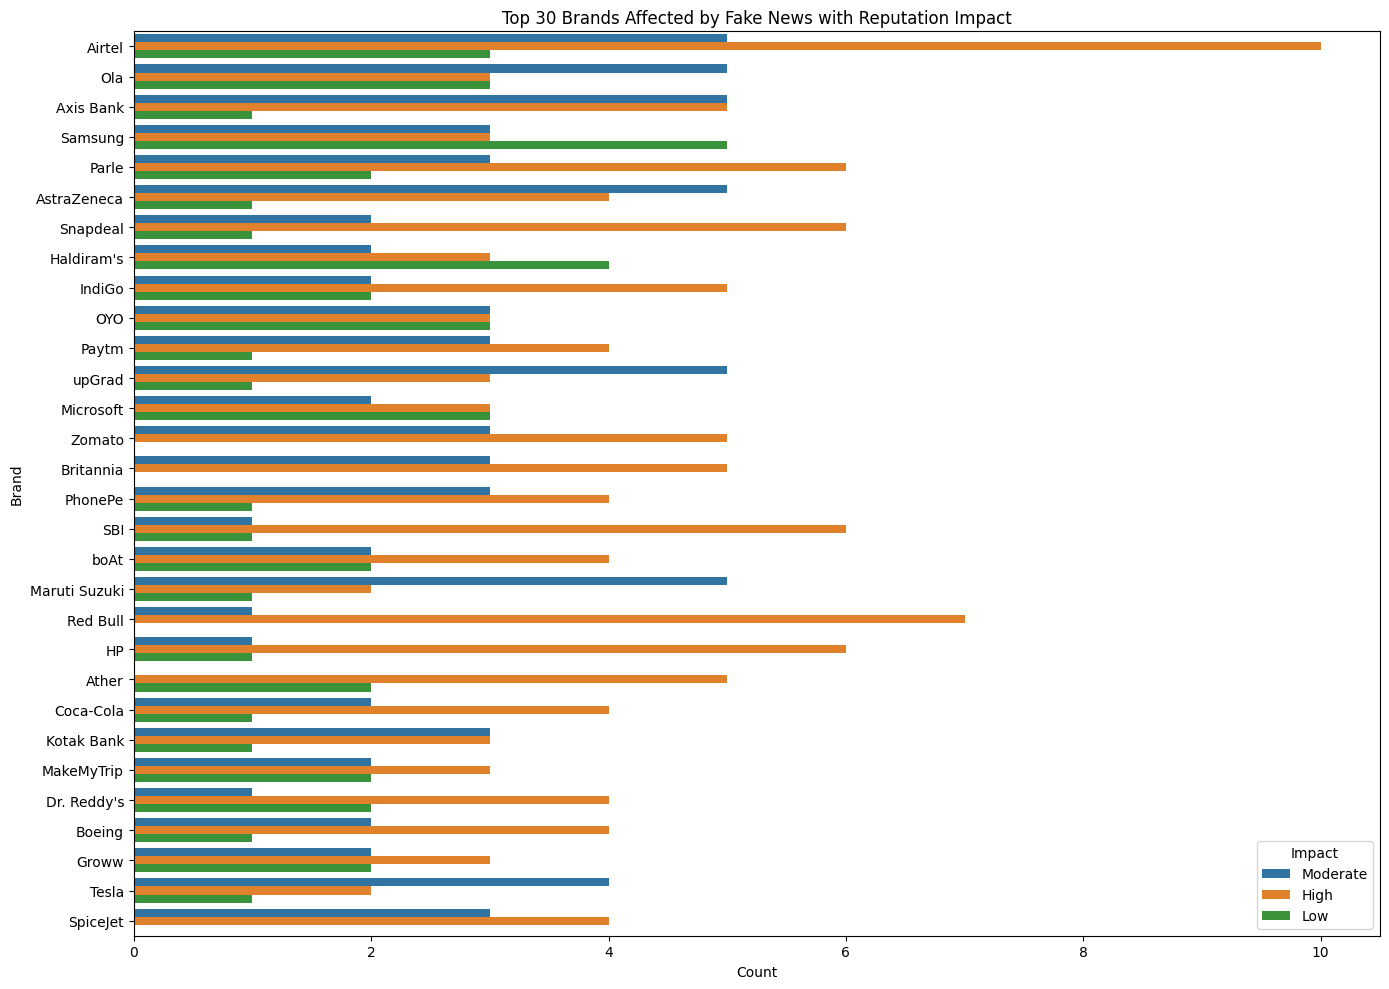

In [ ]:
plt.figure(figsize=(14, 10))
sns.countplot(y='Brand', hue='Brand_Reputation_Impact', data=filtered_fake_df, order=top_30_brands)
plt.title("Top 30 Brands Affected by Fake News with Reputation Impact")
plt.xlabel("Count")
plt.ylabel("Brand")
plt.legend(title="Impact")
plt.tight_layout()
plt.show()

In [ ]:
impact_pivot = filtered_fake_df.pivot_table(
    index='Brand',
    columns='Brand_Reputation_Impact',
    aggfunc='size',
    fill_value=0
)

impact_pivot['Total_Impacts'] = impact_pivot.sum(axis=1)
impact_pivot['High_Impact_Percentage'] = (impact_pivot['High'] / impact_pivot['Total_Impacts']) * 100

display(impact_pivot.sort_values(by='High_Impact_Percentage', ascending=False)[['High', 'Total_Impacts', 'High_Impact_Percentage']].head(10))

Brand_Reputation_Impact,High,Total_Impacts,High_Impact_Percentage
Brand,,,
Red Bull,7,8,87.500000
HP,6,8,75.000000
SBI,6,8,75.000000
Ather,5,7,71.428571
Snapdeal,6,9,66.666667
Britannia,5,8,62.500000
Zomato,5,8,62.500000
Boeing,4,7,57.142857
Coca-Cola,4,7,57.142857


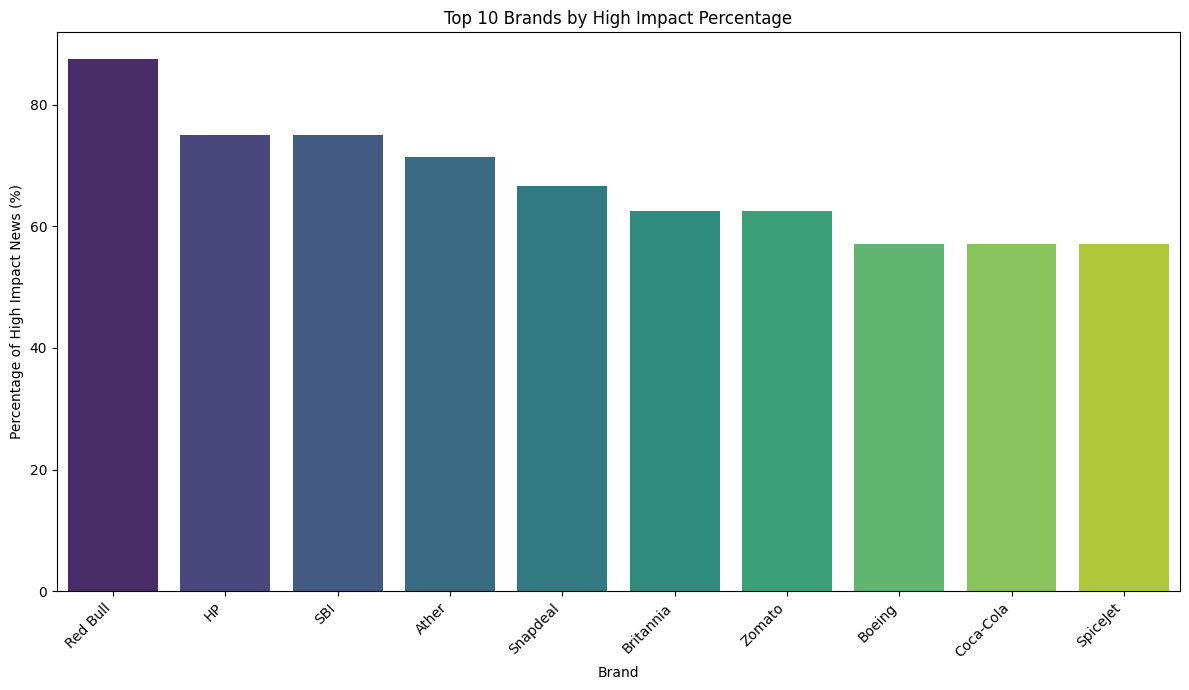

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x=impact_pivot.sort_values(by='High_Impact_Percentage', ascending=False).head(10).index,
            y=impact_pivot.sort_values(by='High_Impact_Percentage', ascending=False).head(10)['High_Impact_Percentage'],
            hue=impact_pivot.sort_values(by='High_Impact_Percentage', ascending=False).head(10).index,
            palette='viridis',
            legend=False)
plt.title('Top 10 Brands by High Impact Percentage')
plt.xlabel('Brand')
plt.ylabel('Percentage of High Impact News (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

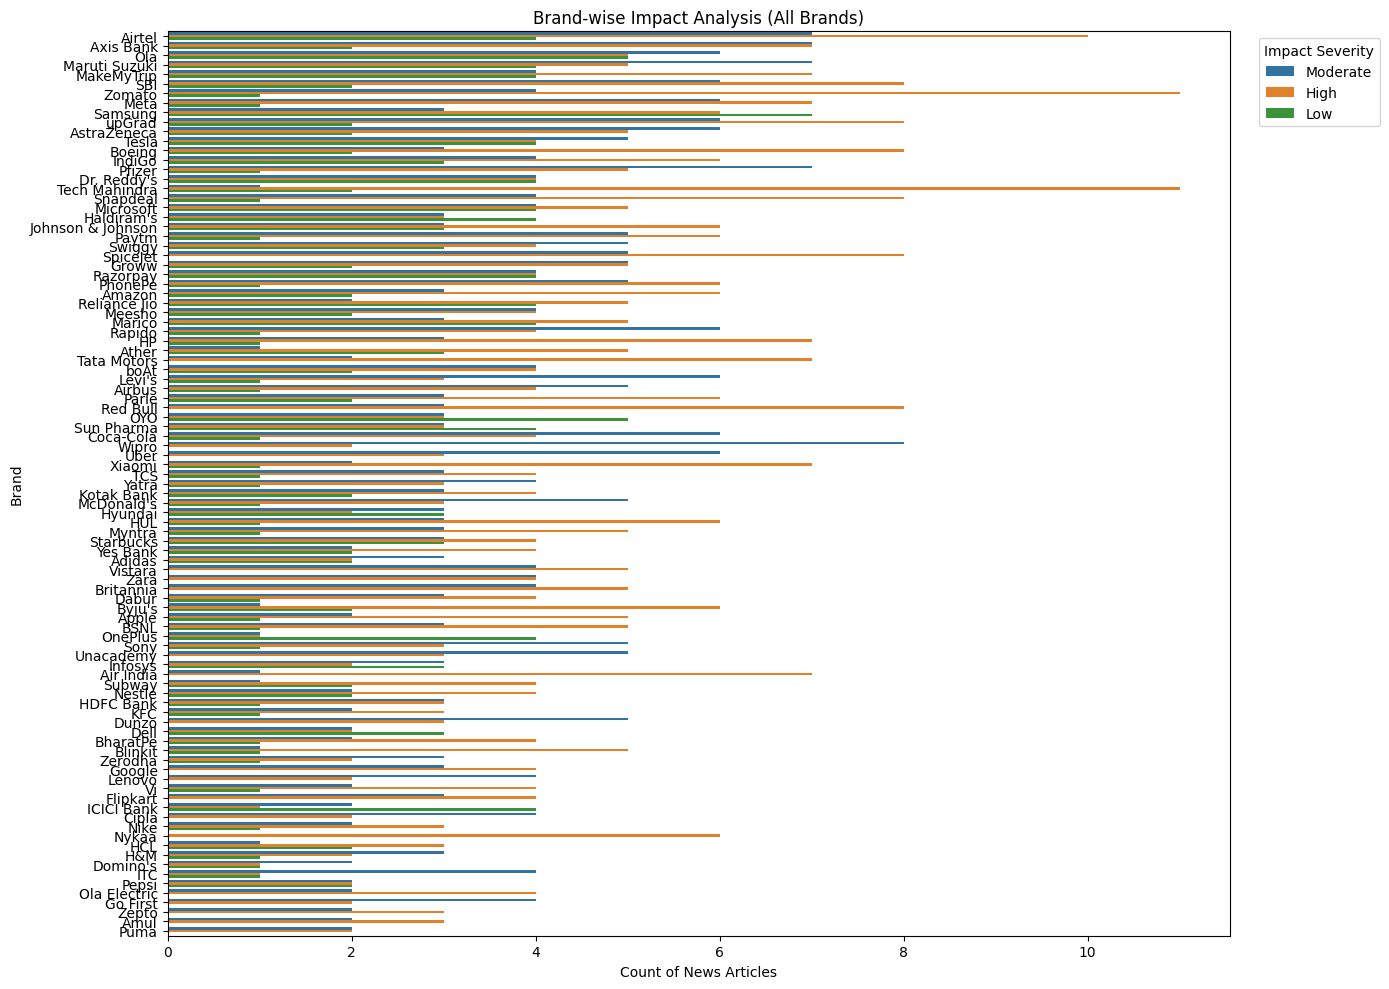

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))  # Set a large figure size for clarity

sns.countplot(
    data=df,
    y='Brand',            # Use 'Brand' on the y-axis for better readability of many brand names
    hue='Brand_Reputation_Impact', # Differentiate impact types with color
    order=df['Brand'].value_counts().index # Order brands by their total count for better visualization
)

plt.title("Brand-wise Impact Analysis (All Brands)")
plt.xlabel("Count of News Articles")
plt.ylabel("Brand")
plt.legend(title="Impact Severity", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()